In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "mahmudulhasantasin/data-science-bowl-2018-competition-merged-mask"
)

print("Dataset path:", path)

DATASET_PATH = os.path.join(path, "data science bowl 2018", "stage1_train")

Using Colab cache for faster access to the 'data-science-bowl-2018-competition-merged-mask' dataset.
Dataset path: /kaggle/input/data-science-bowl-2018-competition-merged-mask


Using Colab cache for faster access to the 'data-science-bowl-2018-competition-merged-mask' dataset.
Downloaded to: /kaggle/input/data-science-bowl-2018-competition-merged-mask
Using dataset folder: /kaggle/input/data-science-bowl-2018-competition-merged-mask/data science bowl 2018/stage1_train 2

---------------------------------
Image 1
Ground Truth nuclei: 10
Naive Watershed nuclei: 13
Marker Distance 2 nuclei: 12
Marker Distance 3 nuclei: 10
Marker Distance 5 nuclei: 9
Marker Distance 8 nuclei: 9
Marker Distance 10 nuclei: 9


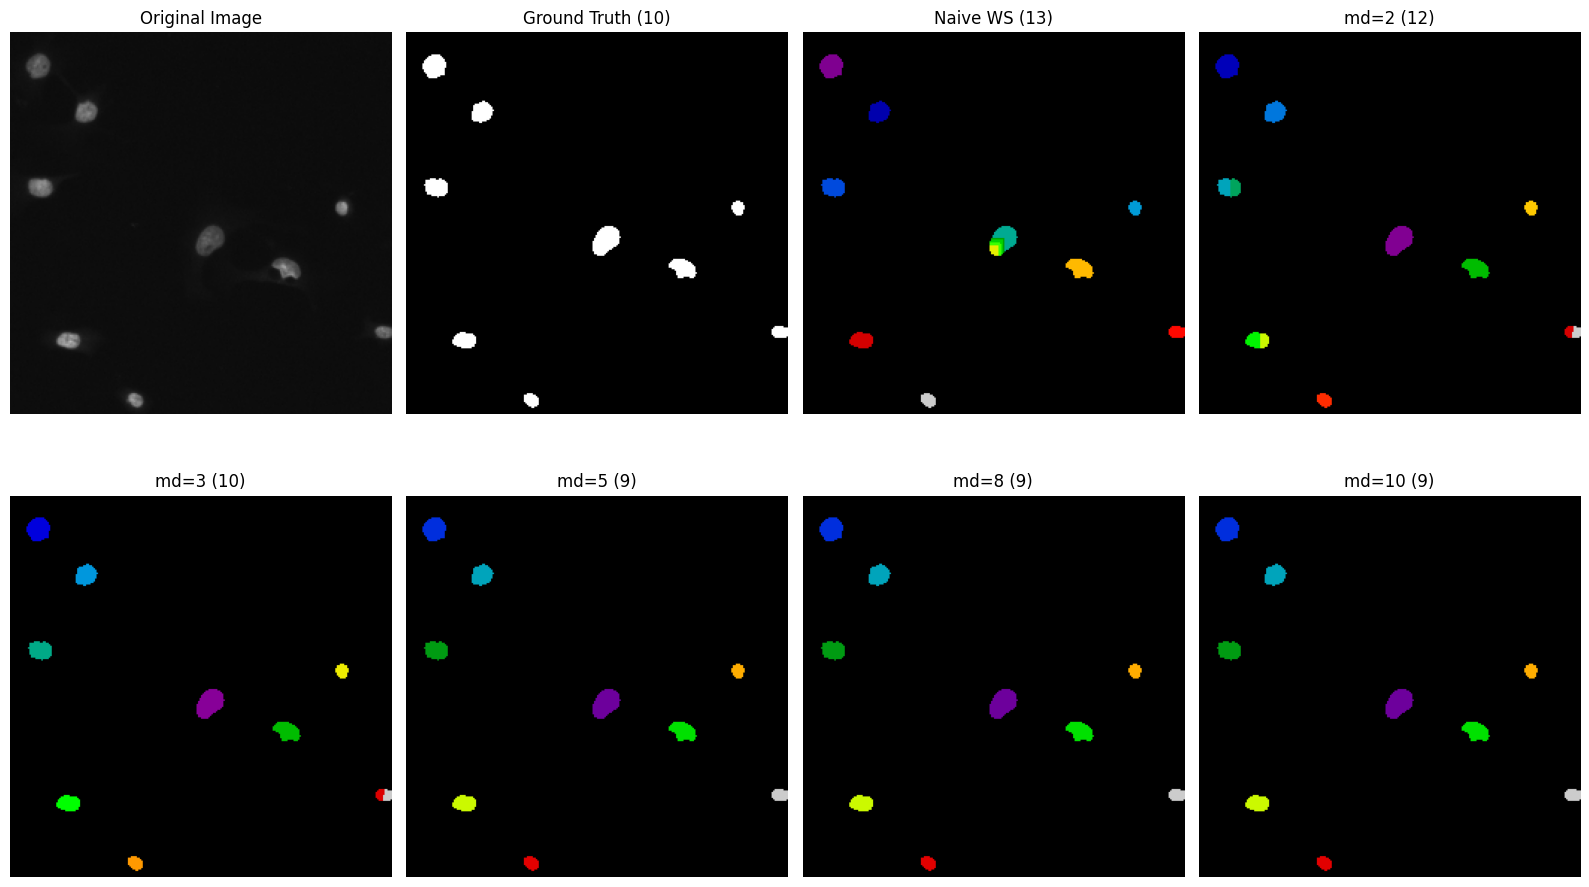


---------------------------------
Image 2
Ground Truth nuclei: 24
Naive Watershed nuclei: 31
Marker Distance 2 nuclei: 32
Marker Distance 3 nuclei: 25
Marker Distance 5 nuclei: 22
Marker Distance 8 nuclei: 17
Marker Distance 10 nuclei: 16


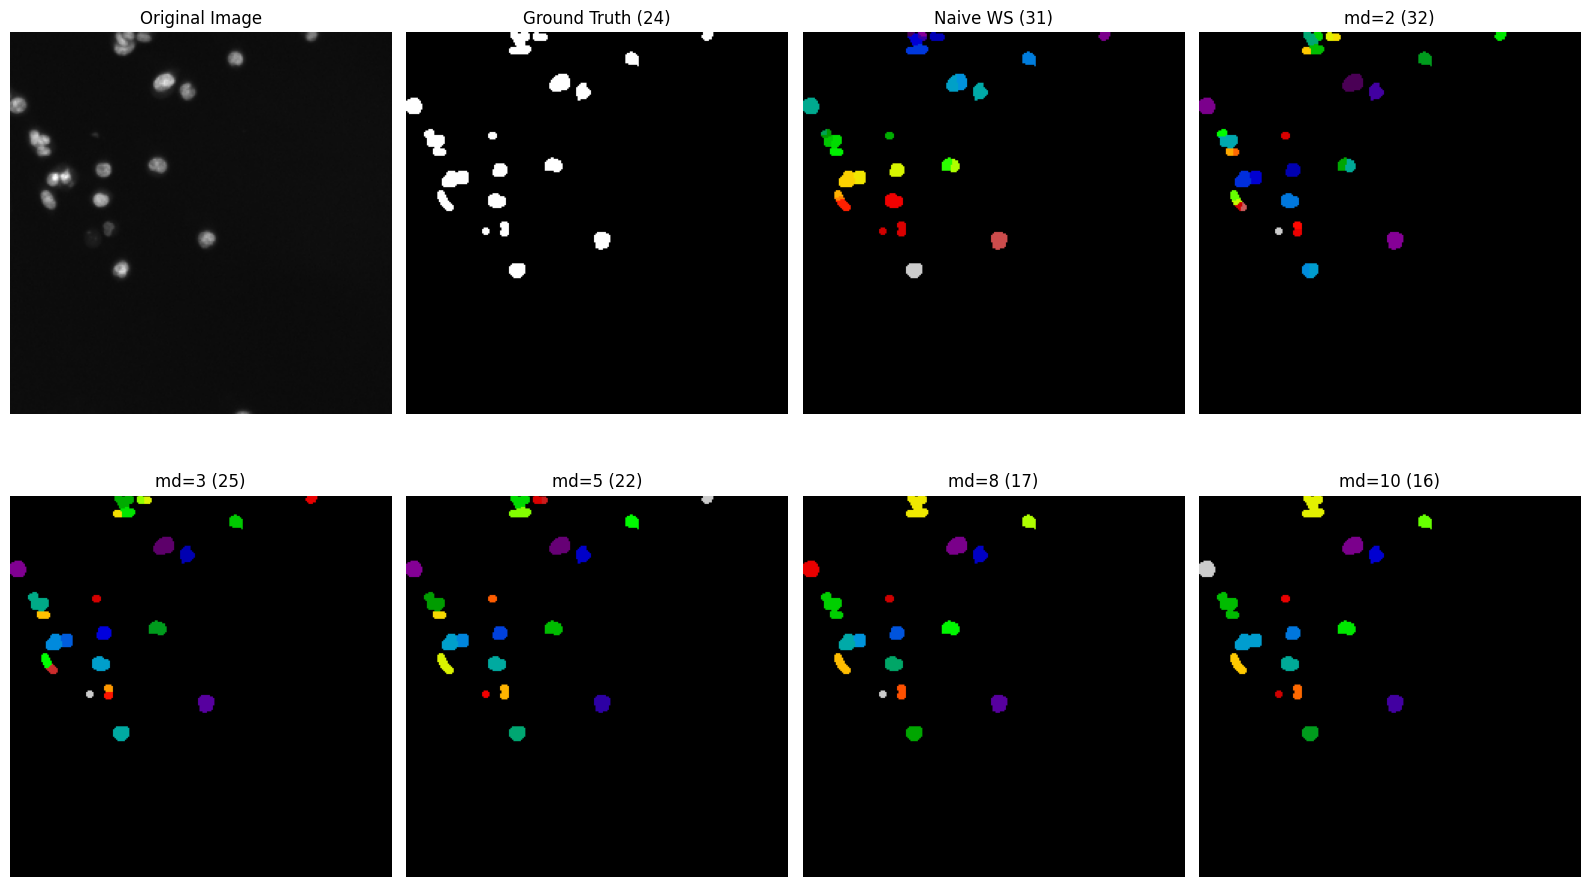


---------------------------------
Image 3
Ground Truth nuclei: 10
Naive Watershed nuclei: 13
Marker Distance 2 nuclei: 11
Marker Distance 3 nuclei: 10
Marker Distance 5 nuclei: 9
Marker Distance 8 nuclei: 9
Marker Distance 10 nuclei: 9


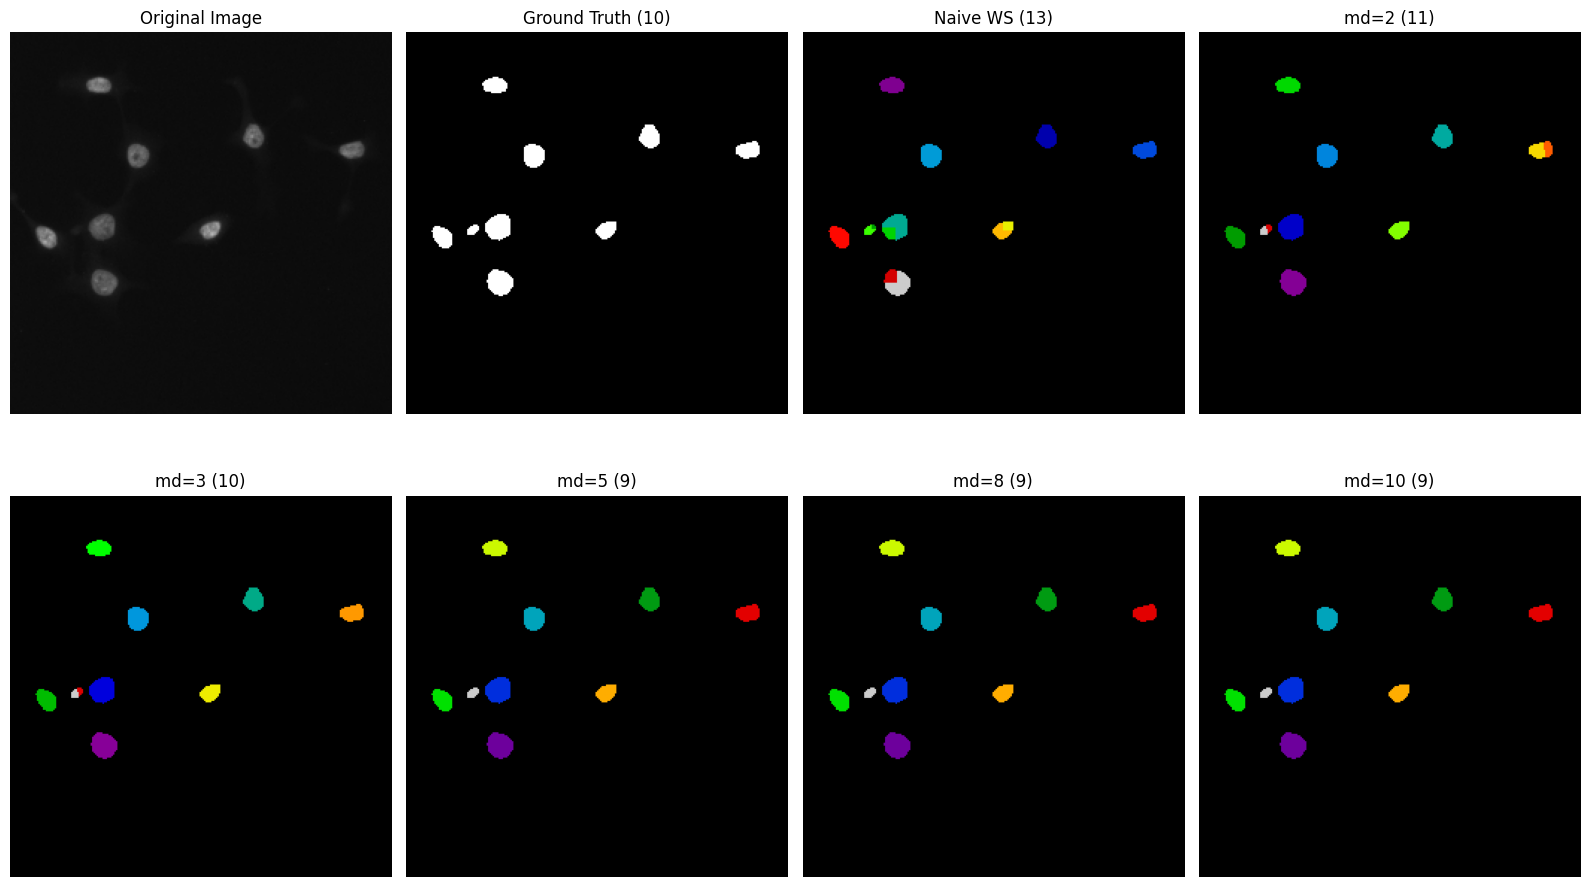


---------------------------------
Image 4
Ground Truth nuclei: 5
Naive Watershed nuclei: 6
Marker Distance 2 nuclei: 4
Marker Distance 3 nuclei: 3
Marker Distance 5 nuclei: 3
Marker Distance 8 nuclei: 3
Marker Distance 10 nuclei: 3


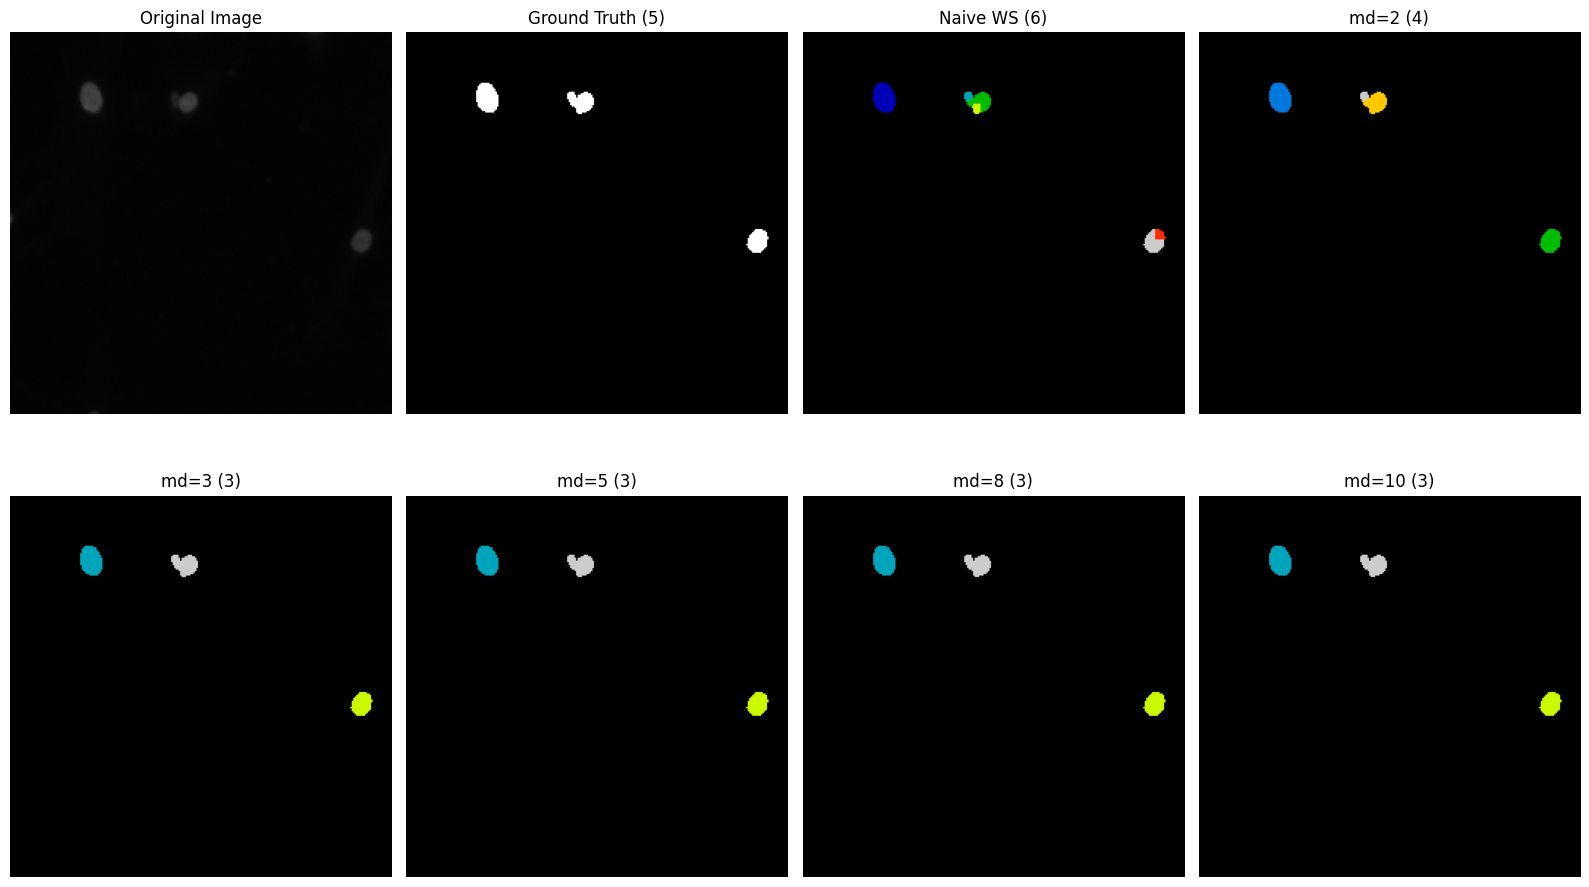


---------------------------------
Image 5
Ground Truth nuclei: 13
Naive Watershed nuclei: 17
Marker Distance 2 nuclei: 18
Marker Distance 3 nuclei: 13
Marker Distance 5 nuclei: 12
Marker Distance 8 nuclei: 12
Marker Distance 10 nuclei: 11


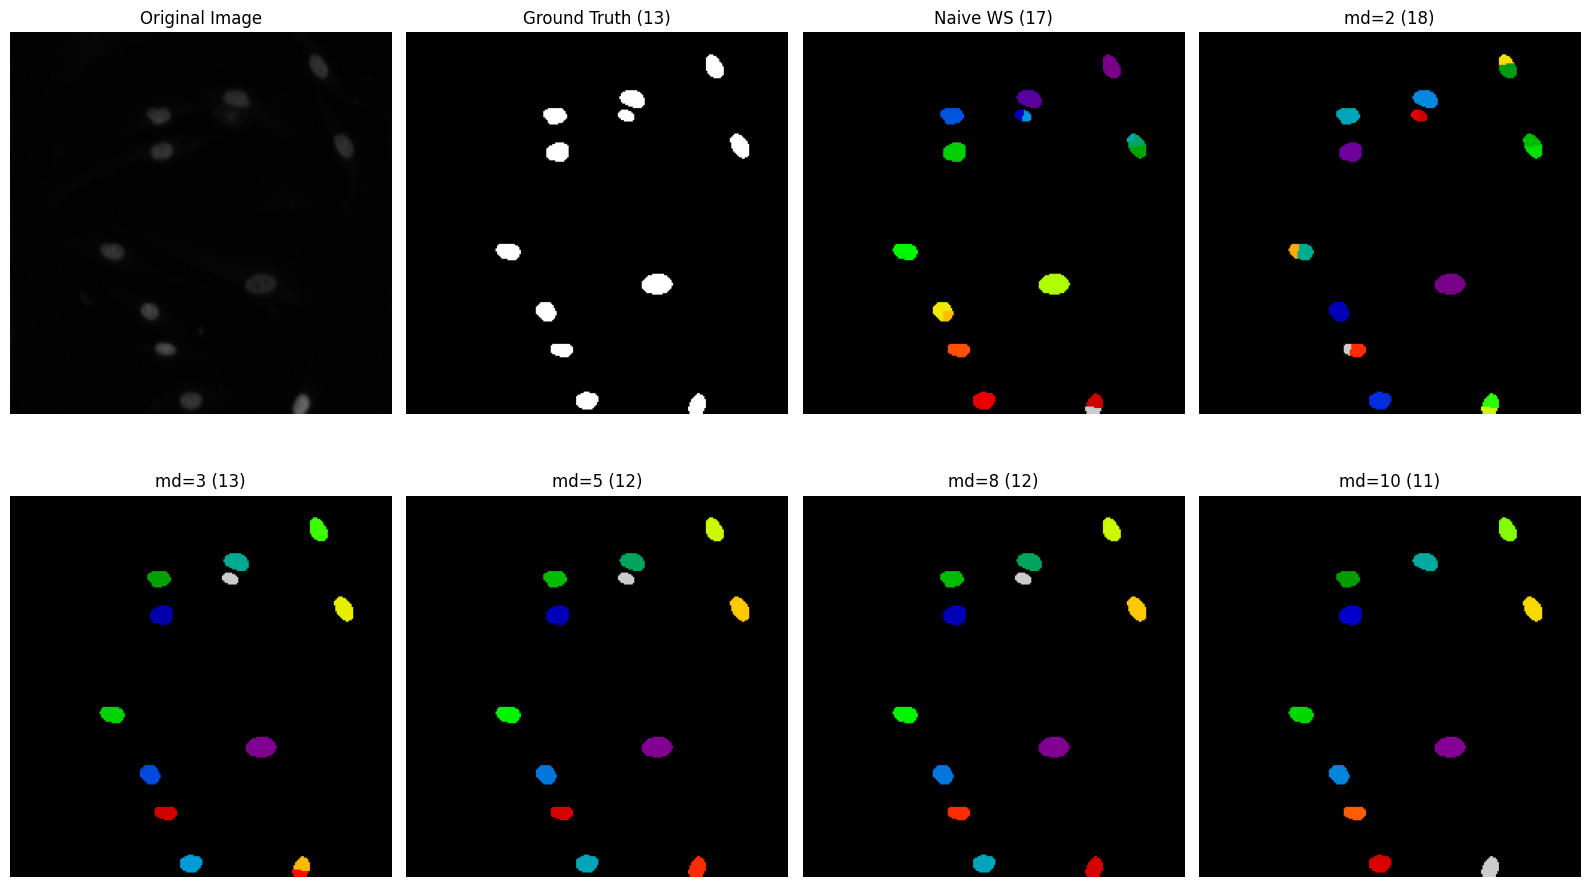

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy.ndimage import distance_transform_edt
import kagglehub


# ------------------------------
# Download Dataset from KaggleHub
# ------------------------------
print("Downloading dataset...")
path = kagglehub.dataset_download(
    "mahmudulhasantasin/data-science-bowl-2018-competition-merged-mask"
)

print("Downloaded to:", path)

# Automatically detect correct folder
base_folder = os.path.join(path, "data science bowl 2018")

if os.path.exists(os.path.join(base_folder, "stage1_train")):
    DATASET_PATH = os.path.join(base_folder, "stage1_train")
elif os.path.exists(os.path.join(base_folder, "stage1_train 2")):
    DATASET_PATH = os.path.join(base_folder, "stage1_train 2")
else:
    raise Exception("stage1_train folder not found!")

print("Using dataset folder:", DATASET_PATH)


# ------------------------------
# Build merged mask
# ------------------------------
def build_merged_mask(mask_dir, shape):
    merged = np.zeros(shape, dtype=np.uint8)

    for file in os.listdir(mask_dir):
        mask_path = os.path.join(mask_dir, file)
        m = cv2.imread(mask_path, 0)

        if m is not None:
            merged = np.maximum(merged, m)

    return (merged > 0).astype(np.uint8)


# ------------------------------
# Watershed without markers
# ------------------------------
def watershed_no_markers(distance, mask):
    return watershed(-distance, mask=mask)


# ------------------------------
# Watershed with markers
# ------------------------------
def watershed_with_markers(distance, mask, min_distance=8):
    coords = peak_local_max(distance, min_distance=min_distance, labels=mask)

    markers = np.zeros(distance.shape, dtype=int)

    for i, (r, c) in enumerate(coords):
        markers[r, c] = i + 1

    return watershed(-distance, markers, mask=mask)


# ------------------------------
# Visualization
# ------------------------------
def visualize_results(image, merged_mask, naive_labels, results, gt_count):
    plt.figure(figsize=(16, 10))

    plt.subplot(2, 4, 1)
    plt.title("Original Image")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.title(f"Ground Truth ({gt_count})")
    plt.imshow(merged_mask, cmap='gray')
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.title(f"Naive WS ({naive_labels.max()})")
    plt.imshow(naive_labels, cmap='nipy_spectral')
    plt.axis("off")

    subplot_index = 4
    for md, labels in results.items():
        plt.subplot(2, 4, subplot_index)
        plt.title(f"md={md} ({labels.max()})")
        plt.imshow(labels, cmap='nipy_spectral')
        plt.axis("off")
        subplot_index += 1

    plt.tight_layout()
    plt.show()


# ------------------------------
# Main Loop
# ------------------------------
MAX_IMAGES = 5
count = 0
marker_distances = [2, 3, 5, 8, 10]

for folder in os.listdir(DATASET_PATH):

    if count >= MAX_IMAGES:
        break

    sample_path = os.path.join(DATASET_PATH, folder)
    img_dir = os.path.join(sample_path, "images")
    mask_dir = os.path.join(sample_path, "masks")

    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        continue

    img_file = os.listdir(img_dir)[0]
    image = cv2.imread(os.path.join(img_dir, img_file))

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    merged_mask = build_merged_mask(mask_dir, gray.shape)
    gt_count = len(os.listdir(mask_dir))

    print("\n---------------------------------")
    print(f"Image {count + 1}")
    print("Ground Truth nuclei:", gt_count)

    distance = distance_transform_edt(merged_mask)

    naive_labels = watershed_no_markers(distance, merged_mask)
    print("Naive Watershed nuclei:", naive_labels.max())

    results = {}
    for md in marker_distances:
        labels = watershed_with_markers(distance, merged_mask, md)
        results[md] = labels
        print(f"Marker Distance {md} nuclei:", labels.max())

    visualize_results(image, merged_mask, naive_labels, results, gt_count)

    count += 1